In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow import keras
from tensorflow.keras import layers

In [2]:
# Constants
L = 0.2          # length (m)
b = 0.01         # width (m)
h = 0.01         # height (m)
E = 1e7          # Young's modulus (N/m^2)
g = 0.05         # gap for switch to turn on
I = (b * h**3) / 12

In [3]:
def compute_deflection(F, V):
    w = 0.1 * V**2

#calculating deflection of beam when force acts at its end
    end_F = (F * L**3) / (3 * E * I) 
#calculating deflection of beam when uniform force acts over entire beam
    uniform_F = (w * L**4) / (8 * E * I)

    return end_F + uniform_F

In [ ]:
N = 5000   #Number of samples

F = np.random.uniform(0, 5, N)      
V = np.random.uniform(0, 10, N)     
delta = compute_deflection(F, V) #Generating random values of F and V and computing total deflection of the beam

y = np.logical_and(delta > g, delta < 6*g).astype(int)    #.astype(int) converts Boolean True and False to 0 and 1. 1 = suitable, 0 = not suitable

X = np.column_stack((F, V))  #converting input values into [F,V]

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=24)  
# dividing both x and y together hence assigning 4 functions; random state is defined to be as 24 for consistency
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=24)

#Since range of each feature can vary in magnitude, we scale the models
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

#defining the models
#We define each model using 3 parameters, the optimiser, loss and metrics. 
model = keras.Sequential([layers.Dense(16, activation='relu', input_shape=(2,)), 
                        layers.Dense(16, activation='relu'), 
                        layers.Dense(1, activation='sigmoid')])
#since it's a classification problem, we use the sigmoid function as our final activation function. Converts it into a probability
#ReLU is used in middle layers cause it takes out negative values

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
#mse for sigmoid function is given using binary cross entropy

history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=60, batch_size=32)

Epoch 1/60


c:\Users\kaash\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8248 - loss: 0.4853 - val_accuracy: 0.8680 - val_loss: 0.3140
Epoch 2/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8942 - loss: 0.2348 - val_accuracy: 0.9100 - val_loss: 0.2042
Epoch 3/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9337 - loss: 0.1709 - val_accuracy: 0.9360 - val_loss: 0.1651
Epoch 4/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9490 - loss: 0.1409 - val_accuracy: 0.9440 - val_loss: 0.1408
Epoch 5/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9567 - loss: 0.1200 - val_accuracy: 0.9580 - val_loss: 0.1195
Epoch 6/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9650 - loss: 0.1038 - val_accuracy: 0.9680 - val_loss: 0.1033
Epoch 7/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.0909 - val_accuracy: 0.9820 - val_loss: 0.0912
Epoch 8/60
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9830 - loss: 0.0815 - val_accuracy: 0.9780 - val_

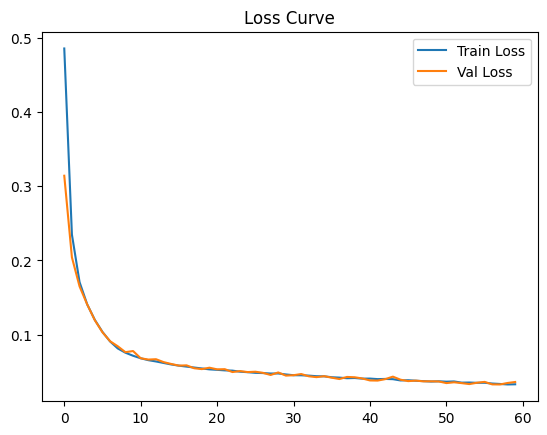

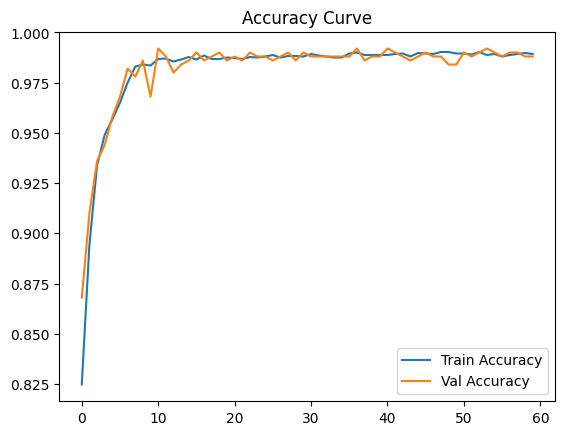

In [6]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()



plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [7]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0408 
Test Accuracy: 0.9819999933242798


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 648us/step


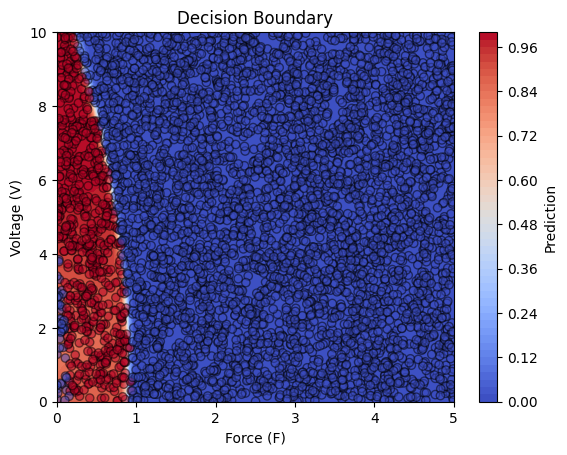

In [8]:
F_range = np.linspace(0, 5, 100)
V_range = np.linspace(0, 10, 100)

F_grid, V_grid = np.meshgrid(F_range, V_range)

grid_points = np.c_[F_grid.ravel(), V_grid.ravel()]
grid_points_scaled = scaler.transform(grid_points)

predictions = model.predict(grid_points_scaled)
predictions = predictions.reshape(F_grid.shape)


plt.contourf(F_grid, V_grid, predictions, levels=50, cmap='coolwarm')
plt.colorbar(label='Prediction')

plt.xlabel("Force (F)")
plt.ylabel("Voltage (V)")
plt.title("Decision Boundary")

plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap='coolwarm', alpha=0.5)

plt.show()